<b>Введение</b>
Цель работы: изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.
Постановка задачи:

Провести обучение модели линейной регрессии на датасете с Kaggle:

Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).

Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной.

Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально).

Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).

Построить регрессионные модели (линейная, лассо и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).

Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA). Перед проведением PCA провести стандартизацию данных.

Повторить шаг 5 (линейная, лассо и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

Описание датасета
Выбранный датасет: влияние факторов(карат, цвет, огранка, прозрачность, размер, глубина, ширина поверхности) на стоимость бриллианта.
С помощью кода, представленного ниже были получены графики рапределения признаков и целевой переменной(цены) и  корреляционая матрица.

Размер датасета: (1002, 10)

Первые строки:
   carat  cut  color  clarity  depth  table  price     x     y     z
0   0.23    5      6        2   61.5   55.0    326  3.95  3.98  2.43
1   0.21    4      6        3   59.8   61.0    326  3.89  3.84  2.31
2   0.23    2      6        5   56.9   65.0    327  4.05  4.07  2.31
3   0.29    4      2        4   62.4   58.0    334  4.20  4.23  2.63
4   0.31    2      1        2   63.3   58.0    335  4.34  4.35  2.75

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1002 entries, 0 to 1001
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    1002 non-null   float64
 1   cut      1002 non-null   int8   
 2   color    1002 non-null   int8   
 3   clarity  1002 non-null   int8   
 4   depth    1002 non-null   float64
 5   table    1002 non-null   float64
 6   price    1002 non-null   int64  
 7   x        1002 non-null   float64
 8   y        1002 non-null   flo

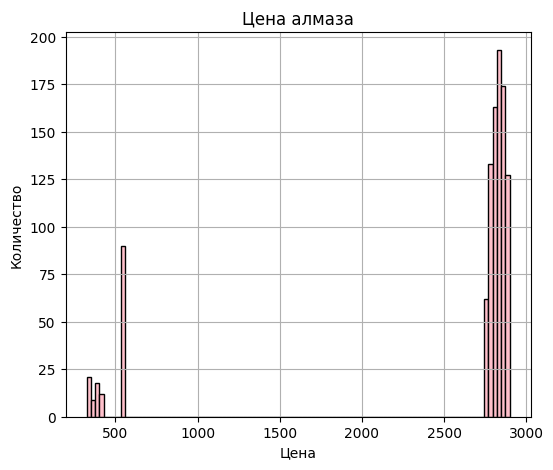

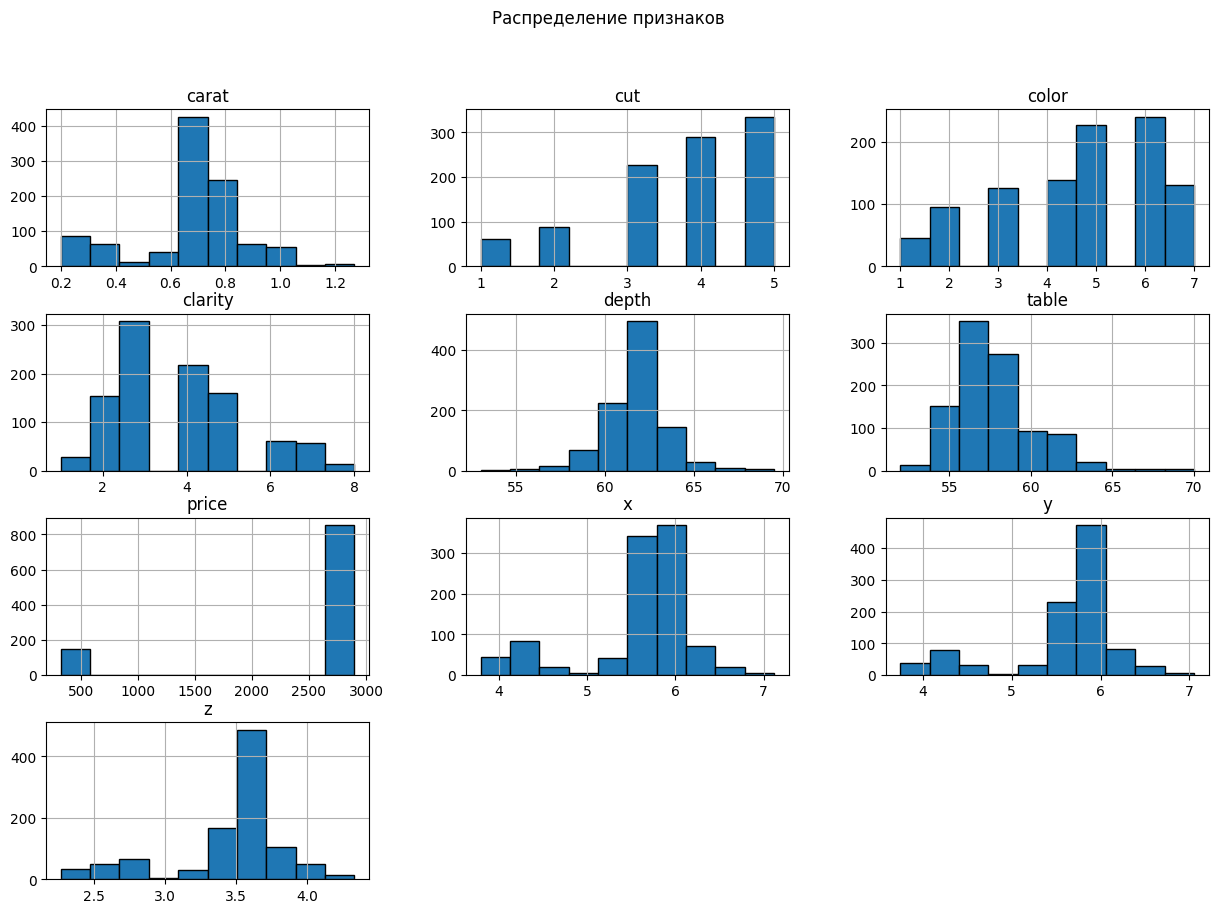

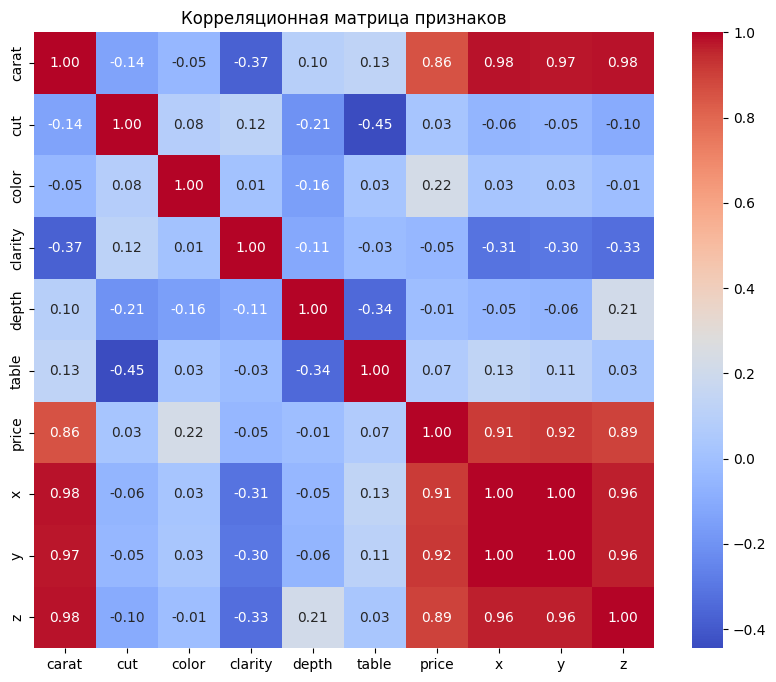

            carat       cut     color   clarity     depth     table     price  \
carat    1.000000 -0.135786 -0.048842 -0.373948  0.095567  0.126415  0.857590   
cut     -0.135786  1.000000  0.081260  0.118582 -0.207052 -0.445238  0.027980   
color   -0.048842  0.081260  1.000000  0.007199 -0.156698  0.028810  0.222858   
clarity -0.373948  0.118582  0.007199  1.000000 -0.113351 -0.027440 -0.045953   
depth    0.095567 -0.207052 -0.156698 -0.113351  1.000000 -0.344946 -0.012163   
table    0.126415 -0.445238  0.028810 -0.027440 -0.344946  1.000000  0.067292   
price    0.857590  0.027980  0.222858 -0.045953 -0.012163  0.067292  1.000000   
x        0.977597 -0.056105  0.026311 -0.311536 -0.049944  0.132024  0.911171   
y        0.972584 -0.045943  0.030287 -0.300587 -0.058115  0.112203  0.917205   
z        0.980879 -0.104552 -0.013101 -0.328230  0.211665  0.031089  0.892967   

                x         y         z  
carat    0.977597  0.972584  0.980879  
cut     -0.056105 -0.045943 

In [29]:

import pandas as pd
import math
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
import seaborn as sns
import numpy as np

df = pd.read_csv("diamonds.csv", sep=",")
df.drop('Unnamed: 0', axis=1, inplace=True)
order = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
df['cut'] = pd.Categorical(df["cut"], categories=order, ordered=True).codes + 1
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]
color_order = ["J", "I", "H", "G", "F", "E", "D"]
df['color'] = pd.Categorical(df["color"], categories=color_order, ordered=True).codes + 1
df['clarity'] = pd.Categorical(df["clarity"], categories=clarity_order, ordered=True).codes + 1

print("Размер датасета:", df.shape)
print("\nПервые строки:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nОписание признаков:")
print(df.describe())

print("\nКоличество пропусков:")
print(df.isnull().sum())

numeric_columns = df.select_dtypes(include=[np.number]).columns

data = {
    'Параметр': [],
    'Асимметрия': [],
    'Эксцесс': []
}

for col in numeric_columns:
    skew_val = skew(df[col].dropna())
    kurt_val = kurtosis(df[col].dropna())
    data['Параметр'].append(col)
    data['Асимметрия'].append(skew_val)
    data['Эксцесс'].append(kurt_val)

summary_df = pd.DataFrame(data)
print(summary_df)
count_of_bins = int(1 + 3.322*math.log10(df.shape[0]))

plt.figure(figsize=(6,5))
df['price'].hist(bins=100,edgecolor="black",color="pink")
plt.ylabel('Количество')
plt.xlabel('Цена')
plt.title("Цена алмаза")
plt.show()

df.hist(bins=count_of_bins, figsize=(15,10), edgecolor="black")
plt.suptitle("Распределение признаков")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Корреляционная матрица признаков")
plt.show()

print(df.corr())

Сильные корреляции (|r| > 0.7)

    x & y: 0.996 — очень сильная положительная

    y & z: 0.962 — очень сильная положительная

    x & z: 0.964 — очень сильная положительная

    carat & z: 0.981 — очень сильная положительная

    carat & x: 0.978 — очень сильная положительная

    carat & y: 0.973 — очень сильная положительная

    price & y: 0.917 — очень сильная положительная

    price & x: 0.911 — очень сильная положительная

    price & z: 0.893 — очень сильная положительная

    price & carat: 0.858 — очень сильная положительная

Умеренные корреляции (0.3 ≤ |r| ≤ 0.7)

    cut & table: −0.445 — умеренная отрицательная

    carat & clarity: −0.374 — умеренная отрицательная

    depth & table: −0.345 — умеренная отрицательная

    clarity & z: −0.328 — умеренная отрицательная

    clarity & x: −0.312 — умеренная отрицательная

    clarity & y: −0.301 — умеренная отрицательная

    price & color: 0.223 — слабо-умеренная положительная

    cut & depth: −0.207 — слабо-умеренная отрицательная

    Подготовка данных. Подробно изложите процедуры предобработки данных (нормализация, заполнение пропусков, разделение выборки на train/test).
    В датасете нет пропущенных данных. 
    Категориальные переменные cut, color, clarity были заменены на ранги(лучшее качество - 1, и все последующие на 2,3...).
    Исходную выборку разделил на тестовую и обучающую в соотношении 20/80 с помощью функции train_test_split. 
    Нормализация произведена с помощью StandardScaler.
    Ниже получены коффиценты VIF для оценки мультиколлинеарности.

In [34]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df.drop("price", axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

vif_data = pd.DataFrame()
vif_data["Переменная"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

print(vif_data)

  Переменная          VIF
8          z  1218.502616
6          x   442.521704
7          y   423.972875
4      depth    85.293987
0      carat    70.938940
5      table     1.927184
1        cut     1.616569
3    clarity     1.386828
2      color     1.224438


Критическая мультиколлинеарность (VIF > 100)

    z — 1218.5

    x — 442.5

    y — 424.0

Практически дублируют друг друга.
Высокая мультиколлинеарность (10 < VIF < 100)

    depth — 85.3

    carat — 70.9

Сильно связаны с размерами (carat ↔ x/y/z ≈ 0.97–0.98).
Норма (VIF < 10)

    table — 1.93

    cut — 1.62

    clarity — 1.39

    color — 1.22


Ход работы.

Построить регрессионные модели (линейная и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).
Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA).

Повторить шаг построения модели (линейная и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

Тестовая и тренировочная 80/20
Линейная регрессия:
  RMSE: 160.484
  R^2: 0.960
  MAPE: 8.726%

Уравнение линейной регрессии:
quality = (-3657.2818)*carat + (32.4005)*cut + (77.3139)*color + (118.7216)*clarity + (-32.7110)*depth + (21.5179)*table + (90.2688)*x + (788.8639)*y + (2580.0516)*z + (-8999.6567)

Гребневая регрессия:
  RMSE: 177.077
  R^2: 0.951
  MAPE: 8.476%

Уравнение линейной регрессии:
quality = (-940.6818)*carat + (45.2191)*cut + (94.4633)*color + (139.7990)*clarity + (45.6378)*depth + (12.6509)*table + (368.6645)*x + (945.9181)*y + (536.1651)*z + (-10777.1675)
K-блочная кросс-валидация (6 фолдов)
Фолд 1: R^2 линейной регрессии = 0.961, R^2 гребневой регрессии = 0.954
Фолд 2: R^2 линейной регрессии = 0.960, R^2 гребневой регрессии = 0.949
Фолд 3: R^2 линейной регрессии = 0.960, R^2 гребневой регрессии = 0.960
Фолд 4: R^2 линейной регрессии = 0.967, R^2 гребневой регрессии = 0.960
Фолд 5: R^2 линейной регрессии = 0.942, R^2 гребневой регрессии = 0.928
Фолд 6: R^2 линейно

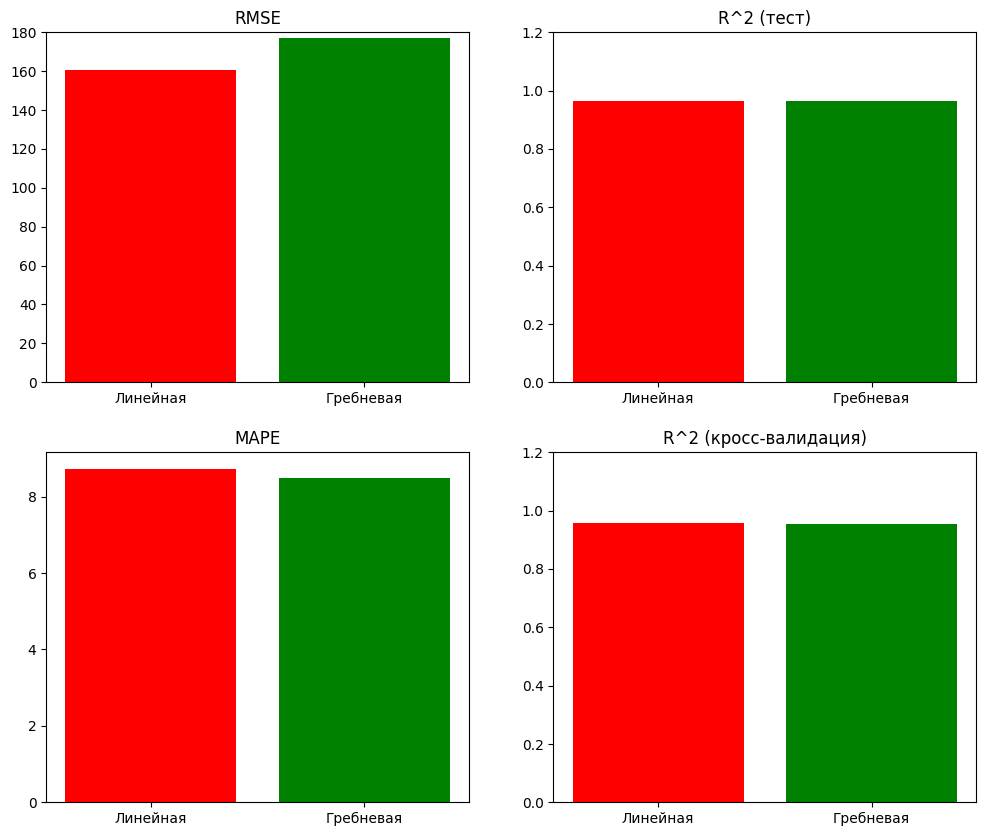

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt

X = df.drop(columns=['price'])
y = df['price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model_lin = LinearRegression()
model_lin.fit(X_train, y_train)
y_pred_lin = model_lin.predict(X_test)

model_ridge  = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)


rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)
mape_lin = mean_absolute_percentage_error(y_test, y_pred_lin) * 100

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge) * 100


feature_names = X.columns.tolist()

print('Тестовая и тренировочная 80/20')

print('Линейная регрессия:')
print(f'  RMSE: {rmse_lin:.3f}')
print(f'  R^2: {r2_lin:.3f}')
print(f'  MAPE: {mape_lin:.3f}%')

lr_equation = "quality = "
lr_equation += " + ".join([f"({model_lin.coef_[i]:.4f})*{col}" for i, col in enumerate(feature_names)])
lr_equation += f" + ({model_lin.intercept_:.4f})"
print("\nУравнение линейной регрессии:")
print(lr_equation)

print('\nГребневая регрессия:')
print(f'  RMSE: {rmse_ridge:.3f}')
print(f'  R^2: {r2_ridge:.3f}')
print(f'  MAPE: {mape_ridge:.3f}%')

lr_equation = "quality = "
lr_equation += " + ".join([f"({model_ridge.coef_[i]:.4f})*{col}" for i, col in enumerate(feature_names)])
lr_equation += f" + ({model_ridge.intercept_:.4f})"
print("\nУравнение линейной регрессии:")
print(lr_equation)

print('K-блочная кросс-валидация (6 фолдов)')
kf = KFold(n_splits=6, shuffle=True, random_state=42)
r2_scores_lin = []
r2_scores_ridge = []

for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    model_lin_fold = LinearRegression()
    model_lin_fold.fit(X_train_fold, y_train_fold)
    y_pred_lin_fold = model_lin_fold.predict(X_test_fold)
    r2_lin = r2_score(y_test_fold, y_pred_lin_fold)
    r2_scores_lin.append(r2_lin)

    model_ridge_fold = Ridge(alpha=1.0)
    model_ridge_fold.fit(X_train_fold, y_train_fold)
    y_pred_ridge_fold = model_ridge_fold.predict(X_test_fold)
    r2_ridge = r2_score(y_test_fold, y_pred_ridge_fold)
    r2_scores_ridge.append(r2_ridge)

    print(f'Фолд {fold}: R^2 линейной регрессии = {r2_lin:.3f}, R^2 гребневой регрессии = {r2_ridge:.3f}')

print(f'\nСреднее R^2 линейной регрессии: {np.mean(r2_scores_lin):.3f}')
print(f'Среднее R^2 гребневой регрессии: {np.mean(r2_scores_ridge):.3f}')

metrics_names = ['RMSE', 'R^2 (тест)', 'MAPE', 'R^2 (кросс)']

lin_metrics = [rmse_lin, r2_lin, mape_lin, np.mean(r2_scores_lin)]
ridge_metrics = [rmse_ridge, r2_ridge, mape_ridge, np.mean(r2_scores_ridge)]

x = np.arange(1)
width = 0.35

fig, axs = plt.subplots(2, 2, figsize=(12, 10))


axs[0, 0].bar(['Линейная', 'Гребневая'], [rmse_lin, rmse_ridge], color=['red', 'green'])
axs[0, 0].set_title('RMSE')


axs[0, 1].bar(['Линейная', 'Гребневая'], [r2_lin, r2_ridge], color=['red', 'green'])
axs[0, 1].set_title('R^2 (тест)')


axs[1, 0].bar(['Линейная', 'Гребневая'], [mape_lin, mape_ridge], color=['red', 'green'])
axs[1, 0].set_title('MAPE')


axs[1, 1].bar(['Линейная', 'Гребневая'], [np.mean(r2_scores_lin), np.mean(r2_scores_ridge)], color=['red', 'green'])
axs[1, 1].set_title('R^2 (кросс-валидация)')

axs[0, 0].set_ylim([0, 180.0])       
axs[0, 1].set_ylim([0, 1.2])               
axs[1, 1].set_ylim([0, 1.2]) 

plt.show()

Оба алгоритма показывают очень высокие и близкие результаты, что говорит о сильной линейной зависимости между признаками и целевой переменной. 
Значение R² ≈ 0.960 у линейной модели означает, что модель объясняет около 96% дисперсии цены.

RMSE ≈ 160.48 у линейной регрессии говорит о том, что среднее отклонение предсказания от истинной цены составляет примерно 160 единиц. С учетом размерности отличный результат.

MAPE ≈ 8.73% у линейной регрессии указывает на среднюю относительную ошибку порядка 8.7%.
Сравнение уравнений регрессии

K-блочная кросс-валидация (6 фолдов)

    Фолд 1: R² линейной = 0.961, R² гребневой = 0.954

    Фолд 2: R² линейной = 0.960, R² гребневой = 0.949

    Фолд 3: R² линейной = 0.960, R² гребневой = 0.960

    Фолд 4: R² линейной = 0.967, R² гребневой = 0.960

    Фолд 5: R² линейной = 0.942, R² гребневой = 0.928

    Фолд 6: R² линейной = 0.964, R² гребневой = 0.964

    Среднее R² линейной регрессии: 0.959

    Среднее R² гребневой регрессии: 0.952

Разброс значений R² небольшой (от 0.93 до 0.97), что свидетельствует о стабильности моделей на разных подвыборках. Средние значения R² практически совпадают с результатами на тесте (0.96 и 0.95) → модели не переобучены, поведение консистентно на новых данных. 

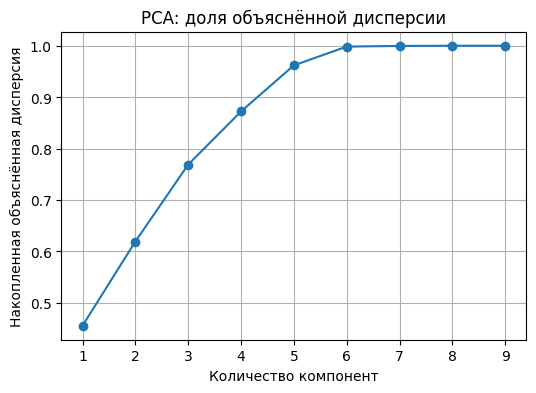

Исходное число признаков: 9
После PCA: 5

Линейная регрессия после PCA:
RMSE: 203.61793365365395
R²: 0.9350760426911601
MAPE: 9.591

Гребневая-регрессия после PCA:
RMSE: 203.5092139767469
R²: 0.9351453551247566
MAPE: 9.600

Фолд 1: R² линейной регрессии = 0.935
Фолд 2: R² линейной регрессии = 0.942
Фолд 3: R² линейной регрессии = 0.949
Фолд 4: R² линейной регрессии = 0.914
Фолд 5: R² линейной регрессии = 0.954
Средний R² линейной регрессии после PCA: 0.939
Фолд 1: R² гребневой регрессии = 0.935
Фолд 2: R² гребневой регрессии = 0.942
Фолд 3: R² гребневой регрессии = 0.949
Фолд 4: R² гребневой регрессии = 0.914
Фолд 5: R² гребневой регрессии = 0.954
Средний R² гребневой регрессии после PCA: 0.939


In [36]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.drop(columns=['price'])
y = df['price']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker="o")
plt.xlabel("Количество компонент")
plt.ylabel("Накопленная объяснённая дисперсия")
plt.title("PCA: доля объяснённой дисперсии")
plt.grid()
plt.show()


pca = PCA(n_components=0.95, random_state=42)
X_reduced = pca.fit_transform(X_scaled)

print("Исходное число признаков:", X.shape[1])
print("После PCA:", X_reduced.shape[1])

X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print("\nЛинейная регрессия после PCA:")
print("RMSE:", rmse)
print("R²:", r2)
print(f"MAPE: {mape:.3f}")

ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

rmse_r = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_r = r2_score(y_test, y_pred_ridge)
mape_r = mean_absolute_percentage_error(y_test, y_pred_ridge) * 100

print("\nГребневая-регрессия после PCA:")
print("RMSE:", rmse_r)
print("R²:", r2_r)
print(f"MAPE: {mape_r:.3f}")

print()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores_lin_pca = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X_reduced), 1):
    X_train_cv, X_val_cv = X_reduced[train_idx], X_reduced[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
    model_cv = LinearRegression()
    model_cv.fit(X_train_cv, y_train_cv)
    y_pred_cv = model_cv.predict(X_val_cv)
    r2_cv = r2_score(y_val_cv, y_pred_cv)
    r2_scores_lin_pca.append(r2_cv)
    print(f'Фолд {fold}: R² линейной регрессии = {r2_cv:.3f}')

print(f'Средний R² линейной регрессии после PCA: {np.mean(r2_scores_lin_pca):.3f}')

r2_scores_ridge_pca = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X_reduced), 1):
    X_train_cv, X_val_cv = X_reduced[train_idx], X_reduced[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
    model_ridge_cv = Ridge(alpha=10)
    model_ridge_cv.fit(X_train_cv, y_train_cv)
    y_pred_ridge_cv = model_ridge_cv.predict(X_val_cv)
    r2_ridge_cv = r2_score(y_val_cv, y_pred_ridge_cv)
    r2_scores_ridge_pca.append(r2_ridge_cv)
    print(f'Фолд {fold}: R² гребневой регрессии = {r2_ridge_cv:.3f}')

print(f'Средний R² гребневой регрессии после PCA: {np.mean(r2_scores_ridge_pca):.3f}')

Было выбрано 5 главных комнент, которые объясняють 95 процентов дисперсии.

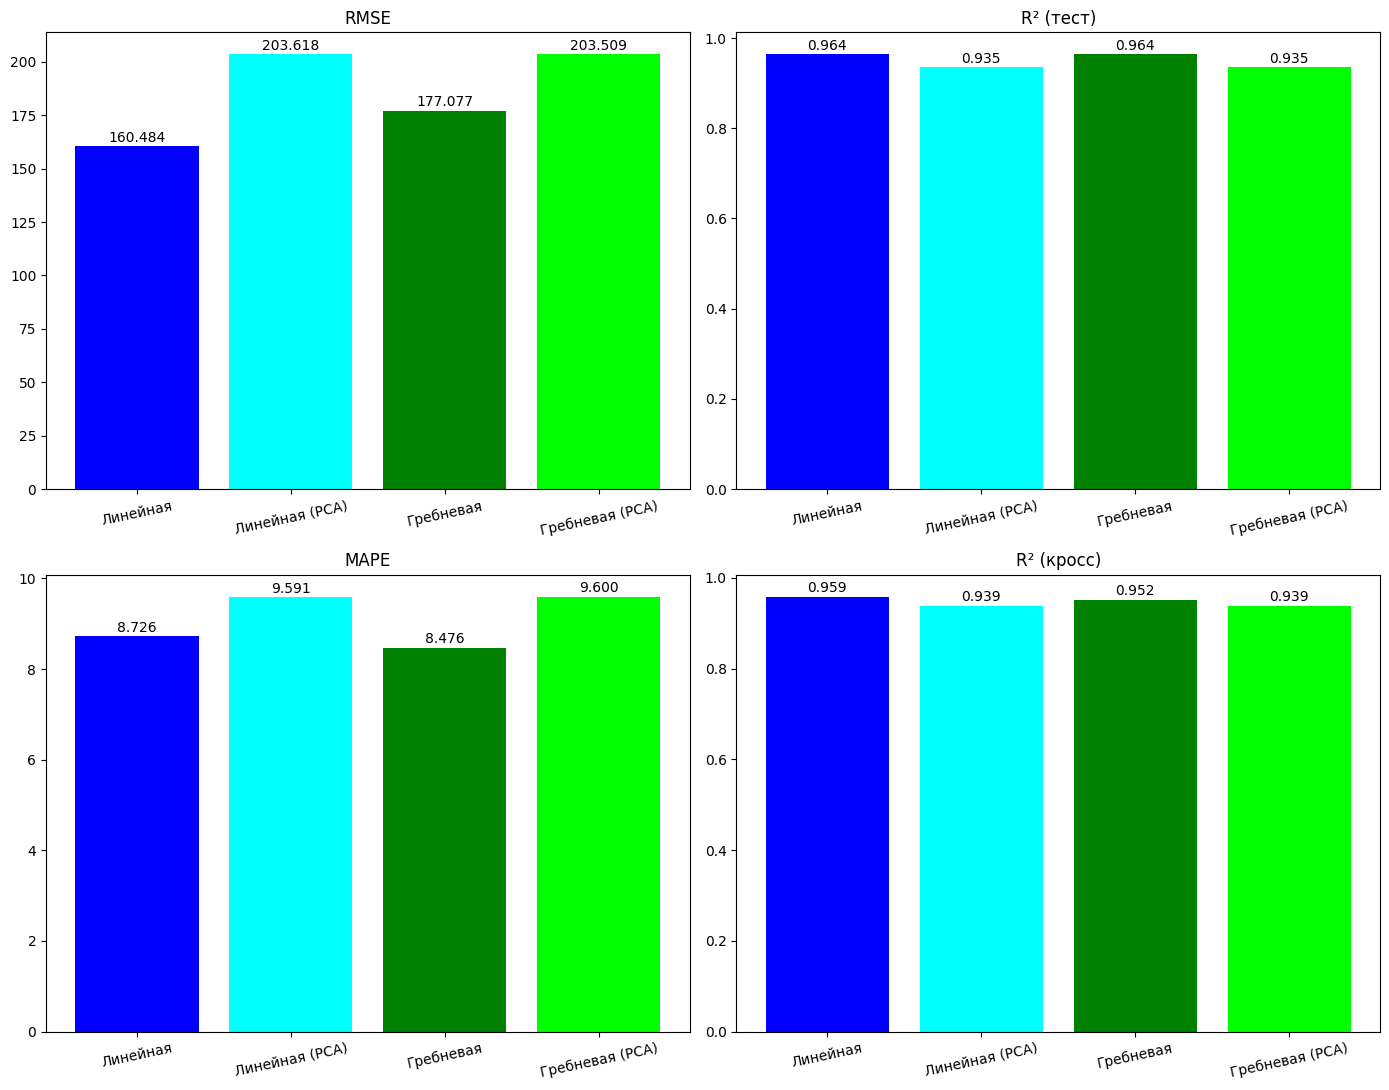

In [37]:

import seaborn as sns
pca_df = pd.DataFrame(X_reduced, columns=[f"PC{i+1}" for i in range(X_reduced.shape[1])])

metrics_names = ["RMSE", "R² (тест)", "MAPE", "R² (кросс)"]


lin_metrics_before = [rmse_lin, r2_lin, mape_lin, np.mean(r2_scores_lin)]
ridge_metrics_before = [rmse_ridge, r2_ridge, mape_ridge, np.mean(r2_scores_ridge)]

lin_metrics_pca = [rmse, r2, mape, np.mean(r2_scores_lin_pca)]
ridge_metrics_pca = [rmse_r, r2_r, mape_r, np.mean(r2_scores_ridge_pca)]

n_groups = len(metrics_names)
bar_width = 0.2
x = np.arange(n_groups)

fig, axs = plt.subplots(2, 2, figsize=(14, 11))


labels = ["Линейная", "Линейная (PCA)", "Гребневая", "Гребневая (PCA)"]

for i, (ax, metric_name) in enumerate(zip(axs.flat, metrics_names)):
    values = [
        lin_metrics_before[i],   
        lin_metrics_pca[i],      
        ridge_metrics_before[i], 
        ridge_metrics_pca[i]     
    ]
    colors = ['blue', 'aqua', 'green', 'lime']
    bars = ax.bar(np.arange(4), values, color=colors)
    ax.set_title(metric_name)
    ax.set_xticks(np.arange(4))
    ax.set_xticklabels(labels, rotation=12)
    for j, rect in enumerate(bars):
        ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.01*max(values), f"{values[j]:.3f}", ha="center")

plt.tight_layout()
plt.show()



По всем показателям модель PCA получилась хуже (абсолютная ошибка увеличилась на 40 пунктов, R^2 на 3 процента, ошибка на 1 процент) как и у линейной, так и у гребневой.
Разброс по фолдам минимальный, что говорит о стабильности модели.
Вывод
По ключевым метрикам средние значения для моделей регрессии составили: RMSE около 160–177, MAPE примерно 8.5–8.7%, R² на тестовой выборке — 0.951–0.960, а усреднённый R² по кросс-валидации — 0.959 для линейной и 0.952 для Ridge-регрессии; аналогичные значения для моделей с PCA: RMSE ~203, MAPE ~9.6%, R² ~0.935. Это говорит о том, что даже при использовании регуляризации и снижения размерности точность моделей ограничена именно избыточностью и коррелированностью размерных признаков, а не сложностью самой зависимости: цена почти линейно определяется каратом и габаритами.
Список источников
https://www.kaggle.com/datasets/shivam2503/diamonds
https://wiki.loginom.ru/articles/multicollinearity.html
https://sky.pro/wiki/analytics/logisticheskaya-regressiya-bazovye-printsipy-i-primenenie-v-analize/
https://sky.pro/wiki/python/kross-validaciya-chto-eto-i-kak-ispolzovat/
https://sky.pro/wiki/analytics/pca-metod-glavnyh-komponent--podrobnyj-analiz-i-primenenie/